In [ ]:
#imports Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

Loading data from drive

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/mirna_classification/boruta/mirna_sig_40.csv")

In [ ]:
print(df.shape)

(99, 42)


In [ ]:
df['Target'].value_counts()

Target
0    85
1    14
Name: count, dtype: int64

In [ ]:
#Distribution of the class
Normal_df= df[df['Target']==1][0:388]
Normal_df

,mirna,hsa-mir-1-1,hsa-mir-1-2,hsa-mir-1301,hsa-mir-130b,hsa-mir-133a-1,hsa-mir-133a-2,hsa-mir-135b,hsa-mir-139,hsa-mir-141,...,hsa-mir-221,hsa-mir-222,hsa-mir-3613,hsa-mir-424,hsa-mir-429,hsa-mir-490,hsa-mir-671,hsa-mir-942,hsa-mir-96,Target
85,Sample86,0.172234,0.199224,0.038247,0.003258,0.990089,1.000000,0.000000,0.629773,0.000472,...,0.001987,0.001019,0.011746,0.019877,0.000751,0.782881,0.036181,0.012757,0.000000,1
86,Sample87,0.185999,0.198054,0.020160,0.005280,0.728313,0.742713,0.000000,0.704130,0.000477,...,0.003981,0.000768,0.021516,0.007979,0.000550,0.437366,0.033139,0.015579,0.002274,1
87,Sample88,0.158452,0.164991,0.009727,0.007243,0.712256,0.671263,0.000686,0.790814,0.001616,...,0.019999,0.014591,0.011659,0.017550,0.001937,0.532737,0.043095,0.029544,0.009856,1
88,Sample89,0.193303,0.193416,0.015878,0.001005,0.890611,0.872601,0.001612,0.616084,0.005327,...,0.010872,0.004124,0.020552,0.013003,0.005953,0.961357,0.067526,0.024800,0.000000,1
89,Sample90,0.264080,0.273154,0.000000,0.000000,0.626986,0.618943,0.000000,0.822831,0.000284,...,0.006725,0.002036,0.002334,0.000000,0.000239,0.466766,0.051755,0.020275,0.001973,1
90,Sample91,0.553217,0.546108,0.013945,0.003008,0.521515,0.517157,0.000000,0.697319,0.000000,...,0.005633,0.002036,0.014001,0.016726,0.000143,0.699773,0.000000,0.008110,0.000000,1
91,Sample92,1.000000,1.000000,0.002044,0.003219,0.549469,0.552147,0.000000,0.784206,0.000360,...,0.010513,0.005962,0.013781,0.009868,0.000596,1.000000,0.031348,0.007675,0.002689,1
92,Sample93,0.235630,0.250203,0.014558,0.009774,0.933510,0.873544,0.000000,0.589503,0.000102,...,0.010767,0.009987,0.007770,0.025259,0.000132,0.981158,0.051060,0.007501,0.002190,1
93,Sample94,0.025514,0.028825,0.017415,0.156638,0.046218,0.040303,0.035431,0.234220,0.234488,...,0.272813,0.190717,0.131181,0.164388,0.266245,0.015467,0.107755,0.302527,0.119114,1
94,Sample95,0.190455,0.199827,0.020363,0.006402,0.621388,0.614825,0.000546,0.851486,0.003027,...,0.017871,0.009359,0.020897,0.012421,0.001306,0.562977,0.051496,0.016811,0.003926,1


In [ ]:
Disease_df= df[df['Target']==0][0:388]
Disease_df

,mirna,hsa-mir-1-1,hsa-mir-1-2,hsa-mir-1301,hsa-mir-130b,hsa-mir-133a-1,hsa-mir-133a-2,hsa-mir-135b,hsa-mir-139,hsa-mir-141,...,hsa-mir-221,hsa-mir-222,hsa-mir-3613,hsa-mir-424,hsa-mir-429,hsa-mir-490,hsa-mir-671,hsa-mir-942,hsa-mir-96,Target
0,Sample1,0.005423,0.009382,0.099179,0.743107,0.021956,0.022673,0.194025,0.141293,0.528647,...,0.170250,0.235586,0.219945,0.485248,0.441925,0.006483,0.346282,0.442356,0.630131,0
1,Sample2,0.016893,0.018021,0.070335,0.130405,0.034635,0.027096,0.056062,0.218621,0.173985,...,0.234518,0.192566,0.099299,0.150638,0.173855,0.017122,0.305876,0.201309,0.096539,0
2,Sample3,0.012798,0.015794,0.044433,0.298064,0.046426,0.056659,0.045401,0.204326,0.663930,...,0.281346,0.207246,0.099827,0.141621,0.778719,0.008827,0.246000,0.106008,0.275683,0
3,Sample4,0.030782,0.038593,0.023145,0.082688,0.095516,0.105126,0.036363,0.187549,0.076273,...,0.078638,0.042339,0.065398,0.134935,0.041940,0.047315,0.102556,0.060264,0.080418,0
4,Sample5,0.004558,0.002458,0.076903,0.155900,0.000000,0.005766,0.184323,0.205714,0.186310,...,0.265192,0.282411,0.070432,0.126661,0.116112,0.002336,0.390518,0.318719,0.156299,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Sample81,0.003583,0.001690,0.162064,0.273766,0.001280,0.005287,0.329014,0.081607,0.239078,...,0.223473,0.416474,0.302735,0.494279,0.196538,0.000000,0.402852,0.306867,0.261048,0
81,Sample82,0.016596,0.016342,0.278991,0.242581,0.096924,0.094766,0.018359,0.536201,0.045074,...,0.468963,0.379720,0.034144,0.087558,0.025931,0.032349,0.204339,0.084759,0.020618,0
82,Sample83,0.004217,0.005883,0.192227,0.222654,0.013625,0.009200,0.809445,0.070229,0.327493,...,0.213121,0.350074,0.319799,0.506718,0.473323,0.000000,0.348218,0.247700,0.261973,0
83,Sample84,0.001243,0.000000,0.109989,0.168099,0.000000,0.007340,0.007910,0.231375,0.110379,...,0.486733,0.565594,0.000000,0.036925,0.095392,0.000000,0.041429,0.657300,0.014212,0


In [ ]:
list(df.columns)

['mirna',
 'hsa-mir-1-1',
 'hsa-mir-1-2',
 'hsa-mir-1301',
 'hsa-mir-130b',
 'hsa-mir-133a-1',
 'hsa-mir-133a-2',
 'hsa-mir-135b',
 'hsa-mir-139',
 'hsa-mir-141',
 'hsa-mir-142',
 'hsa-mir-143',
 'hsa-mir-146a',
 'hsa-mir-146b',
 'hsa-mir-151a',
 'hsa-mir-155',
 'hsa-mir-16-2',
 'hsa-mir-17',
 'hsa-mir-181a-1',
 'hsa-mir-181b-1',
 'hsa-mir-181b-2',
 'hsa-mir-182',
 'hsa-mir-183',
 'hsa-mir-188',
 'hsa-mir-18a',
 'hsa-mir-196b',
 'hsa-mir-1976',
 'hsa-mir-200a',
 'hsa-mir-200b',
 'hsa-mir-200c',
 'hsa-mir-203a',
 'hsa-mir-21',
 'hsa-mir-221',
 'hsa-mir-222',
 'hsa-mir-3613',
 'hsa-mir-424',
 'hsa-mir-429',
 'hsa-mir-490',
 'hsa-mir-671',
 'hsa-mir-942',
 'hsa-mir-96',
 'Target']

In [ ]:
feature_df=df[['hsa-mir-1-1','hsa-mir-1-2','hsa-mir-1301','hsa-mir-130b','hsa-mir-133a-1','hsa-mir-133a-2',
 'hsa-mir-135b','hsa-mir-139','hsa-mir-141','hsa-mir-142','hsa-mir-143','hsa-mir-146a','hsa-mir-146b',
 'hsa-mir-151a','hsa-mir-155','hsa-mir-16-2','hsa-mir-17','hsa-mir-181a-1','hsa-mir-181b-1',
 'hsa-mir-181b-2','hsa-mir-182','hsa-mir-183','hsa-mir-188','hsa-mir-18a','hsa-mir-196b',
 'hsa-mir-1976','hsa-mir-200a','hsa-mir-200b','hsa-mir-200c','hsa-mir-203a','hsa-mir-21',
 'hsa-mir-221','hsa-mir-222','hsa-mir-3613','hsa-mir-424','hsa-mir-429','hsa-mir-490',
 'hsa-mir-671','hsa-mir-942','hsa-mir-96']]

In [ ]:
feature_df
#Independent variable
X= np.asarray(feature_df)
X

array([[0.00542268, 0.0093818 , 0.09917884, ..., 0.34628175, 0.44235571,
        0.63013098],
       [0.01689254, 0.01802067, 0.0703346 , ..., 0.30587643, 0.20130932,
        0.09653906],
       [0.0127982 , 0.01579374, 0.04443341, ..., 0.24600037, 0.10600762,
        0.2756829 ],
       ...,
       [0.18776267, 0.18608455, 0.0071673 , ..., 0.08004382, 0.        ,
        0.00422458],
       [0.21216992, 0.22448638, 0.0123337 , ..., 0.03599243, 0.01269002,
        0.        ],
       [0.22331445, 0.23901833, 0.01440227, ..., 0.03961778, 0.00931215,
        0.        ]])

In [ ]:
#dependent variable
y=np.asarray(df['Target'])
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
pip install imblearn

In [ ]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks
resample = SMOTETomek(tomek=TomekLinks(sampling_strategy='majority'), random_state=42)
X_res, y_res = resample.fit_resample(X,y)

In [ ]:
X.shape

(99, 40)

**split data with balance data**

In [ ]:
#devide data into train/test part
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.30, random_state=42)
X_test.shape

(51, 40)

In [ ]:
# Define base models

base_models = [

('rf', RandomForestClassifier(bootstrap=True,criterion='gini',max_depth=2, max_features='sqrt', n_estimators=60, random_state=42)),

('XGB', XGBClassifier(n_estimators=50, max_depth=3,colsample_bylevel=0.1,colsample_bytree=0.2,min_child_weight=5,reg_alpha=1, reg_lambda=1, learning_rate=0.2, objective='binary:logistic', random_state=42)),
('NB', GaussianNB()),
('GB', GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.05,max_features=7,min_samples_leaf=30,min_samples_split=0.8,subsample=0.9,random_state=42)),
('ADB',AdaBoostClassifier(n_estimators=10, learning_rate=0.0001,algorithm='SAMME',random_state=42)),
('KNN', KNeighborsClassifier())
 ]

In [ ]:
# Define meta-model

meta_model = LogisticRegression()

# Initialize and train the StackingClassifier

stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)


stacking_clf.fit(X_train, y_train)


StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(max_depth=2,
                                                       n_estimators=60,
                                                       random_state=42)),
                               ('XGB',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=0.1,
                                              colsample_bynode=None,
                                              colsample_bytree=0.2, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None, gamma=None,
                                              gro...
                                              random_state=42, ...)),
                               ('NB', GaussianNB()),
                               ('GB',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           max_depth=5,
                                                           max_features=7,
                                                           min_samples_leaf=30,
                                                           min_samples_split=0.8,
                                                           random_state=42,
                                                           subsample=0.9)),
                               ('ADB',
                                AdaBoostClassifier(algorithm='SAMME',
                                                   learning_rate=0.0001,
                                                   n_estimators=10,
                                                   random_state=42)),
                               ('KNN', KNeighborsClassifier())],
                   final_estimator=LogisticRegression())

In [ ]:
# Make predictions

y_pred = stacking_clf.predict(X_test)

# Evaluate the model

accuracy = accuracy_score(y_test, y_pred)

print(f"Stacking Classifier Accuracy: {accuracy:.2f}")

Stacking Classifier Accuracy: 0.96


In [ ]:
from sklearn.metrics import classification_report
stack_predict=stacking_clf.predict(X_test)
print(classification_report(y_test,stack_predict))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        26
           1       1.00      0.92      0.96        25

    accuracy                           0.96        51
   macro avg       0.96      0.96      0.96        51
weighted avg       0.96      0.96      0.96        51



In [ ]:
from sklearn.model_selection import KFold, cross_val_score # Import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=42)
cross_val_scores5 = cross_val_score(stacking_clf, X_res, y_res, cv=kf)
print("Cross Validation Scores are {}".format(cross_val_scores5))
print("Average Cross Validation score :{}".format(cross_val_scores5.mean()))

Cross Validation Scores are [1.         1.         0.88235294 1.         1.         1.
 1.         1.         1.         1.        ]
Average Cross Validation score :0.9882352941176471


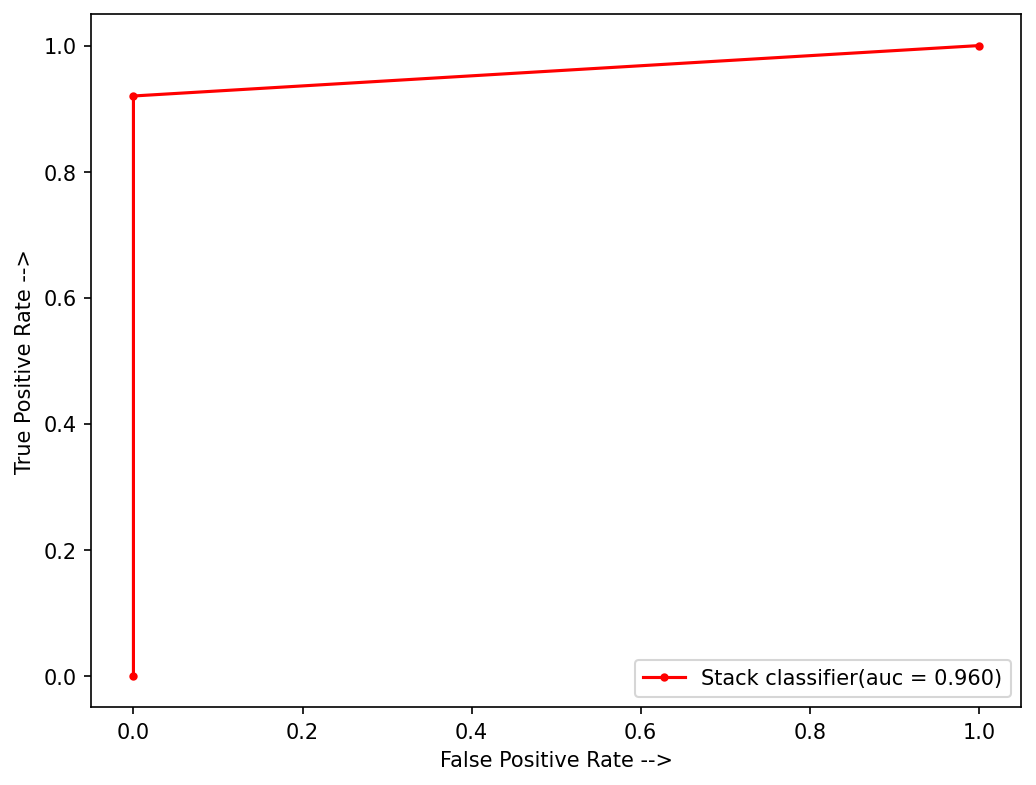

In [ ]:
from sklearn.metrics import roc_curve, auc
model1_fpr, model1_tpr, thresholds = roc_curve(y_test, stack_predict)
auc_model1 = auc(model1_fpr, model1_tpr)



plt.figure(figsize=(8,6), dpi=150)
plt.plot(model1_fpr, model1_tpr, color='red',marker ='.',label='Stack classifier(auc = %0.3f)' % auc_model1)
plt.xlabel('False Positive Rate -->')
plt.ylabel('True Positive Rate -->')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix= confusion_matrix(y_test, stack_predict)

print(conf_matrix)

[[26  0]
 [ 2 23]]


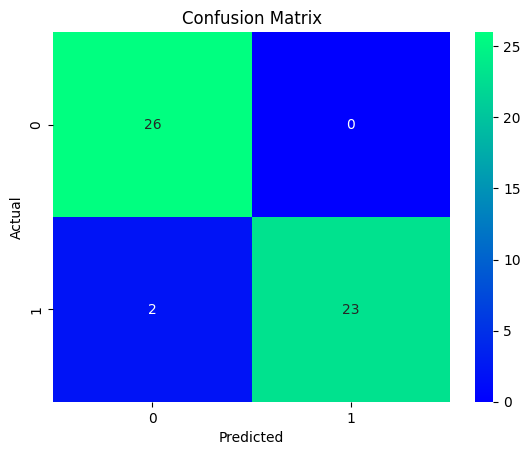

In [ ]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='winter')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()